In [1]:
import pandas as pd

weather = pd.read_csv("../Data/madrid_weather.csv", parse_dates=["time"])

weather.head(24)

C:\Users\User\AppData\Local\Temp\ipykernel_13532\3430900562.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather = pd.read_csv("../Data/madrid_weather.csv", parse_dates=["time"])


,time,temperature,wind_speed,wind_direction,humidity,barometric_pressure,solar_radiation,precipitation
0,2019-01-01 00:59:00,3.1,0.65,64,50,949,0,0.0
1,2019-01-01 01:59:00,2.9,0.95,32,49,949,0,0.0
2,2019-01-01 02:59:00,3.1,0.87,62,46,949,0,0.0
3,2019-01-01 03:59:00,1.9,0.73,75,51,949,0,0.0
4,2019-01-01 04:59:00,0.7,0.57,53,56,949,0,0.0
5,2019-01-01 05:59:00,0.5,0.57,24,53,949,0,0.0
6,2019-01-01 06:59:00,0.0,0.80,345,55,949,0,0.0
7,2019-01-01 07:59:00,-0.8,0.85,78,60,949,0,0.0
8,2019-01-01 08:59:00,0.0,0.90,34,56,949,10,0.0
9,2019-01-01 09:59:00,2.2,0.73,84,48,950,99,0.0


In [2]:
weather.dtypes

time                   datetime64[ns]
temperature                   float64
wind_speed                    float64
wind_direction                  int64
humidity                        int64
barometric_pressure             int64
solar_radiation                 int64
precipitation                 float64
dtype: object

In [3]:
weather.describe()

,time,temperature,wind_speed,wind_direction,humidity,barometric_pressure,solar_radiation,precipitation
count,27024,27024.000000,27024.000000,27024.000000,27024.000000,27024.000000,27024.000000,27024.000000
mean,2020-07-17 00:41:47.317939200,12.817040,2.058503,142.523313,54.560909,940.013433,197.641282,0.045811
min,2019-01-01 00:59:00,-9.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019-10-09 12:44:00,6.400000,1.100000,62.000000,36.000000,938.000000,0.000000,0.000000
50%,2020-07-17 00:29:00,11.400000,1.800000,122.000000,53.000000,941.000000,9.000000,0.000000
75%,2021-04-24 12:14:00,18.800000,2.770000,241.000000,72.000000,944.000000,355.000000,0.000000
max,2022-01-31 23:59:00,37.900000,9.450000,359.000000,100.000000,952.000000,1068.000000,27.400000
std,NaN,8.195516,1.253231,92.795447,22.700106,17.668038,284.877404,0.463671


### EDA & Smoothing

<Axes: xlabel='time'>

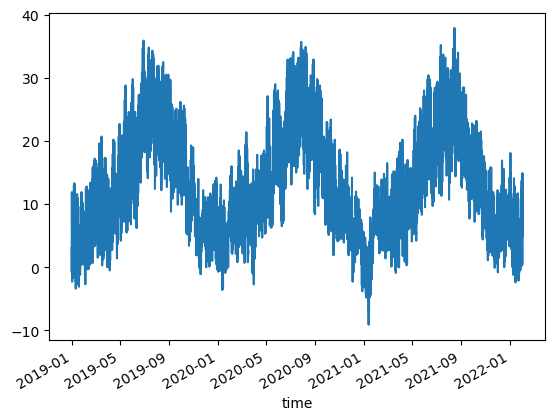

In [4]:
weather.set_index("time").loc[:, "temperature"].plot()

vienos savaitės

<Axes: xlabel='time'>

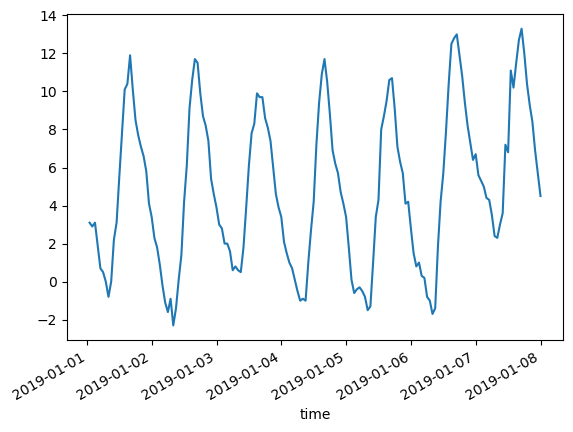

In [5]:
weather.set_index("time").loc[:"2019-01-07", "temperature"].plot()

.rolling()

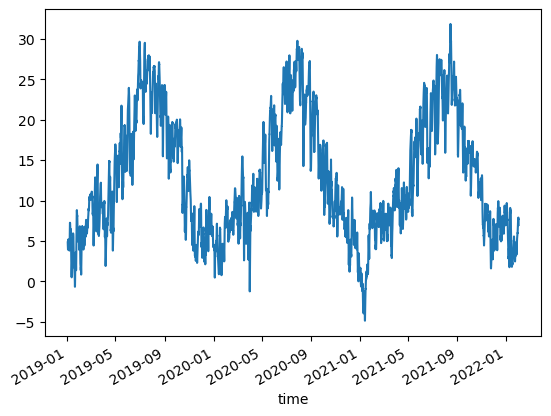

In [6]:
# 24h = daily moving average
weather.set_index("time").loc[:, "temperature"].rolling((24)).mean().plot();

<Axes: xlabel='time'>

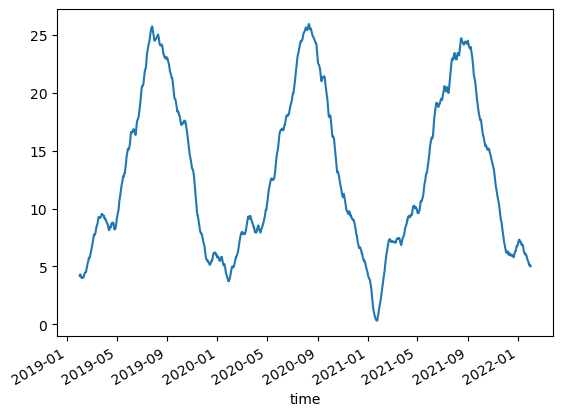

In [7]:

# (24 * 30) = 30-day moving average

weather.set_index("time").loc[:, "temperature"].rolling((24 * 30)).mean().plot()

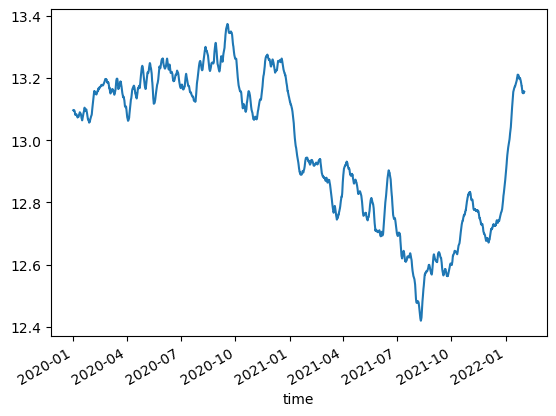

In [8]:
# (24 * 365) = yearly moving average


weather.set_index("time").loc[:, "temperature"].rolling((24 * 365)).mean().plot();

### Decomposition

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

taco_stands = pd.read_csv("../Data/taco_stands.csv", parse_dates=["Date"])

taco_stands.tail(30)

C:\Users\User\AppData\Local\Temp\ipykernel_13532\2253391797.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  taco_stands = pd.read_csv("../Data/taco_stands.csv", parse_dates=["Date"])


,Date,Taco Stands in LA
210,2027-07-01,232
211,2027-08-01,240
212,2027-09-01,233
213,2027-10-01,231
214,2027-11-01,230
215,2027-12-01,228
216,2028-01-01,228
217,2028-02-01,231
218,2028-03-01,231
219,2028-04-01,235


In [10]:
taco_stands.describe()

,Date,Taco Stands in LA
count,240,240.000000
mean,2019-12-16 11:00:00,137.666667
min,2010-01-01 00:00:00,12.000000
25%,2014-12-24 06:00:00,76.750000
50%,2019-12-16 12:00:00,136.500000
75%,2024-12-08 18:00:00,196.250000
max,2029-12-01 00:00:00,264.000000
std,NaN,69.672676


In [11]:
taco_stands.dtypes

Date                 datetime64[ns]
Taco Stands in LA             int64
dtype: object

<Axes: xlabel='Date'>

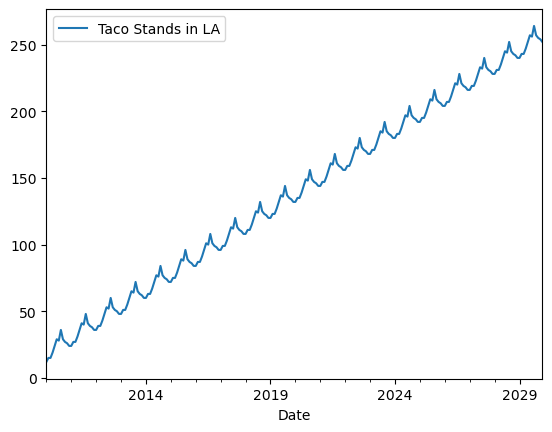

In [12]:
taco_stands.set_index("Date").plot()

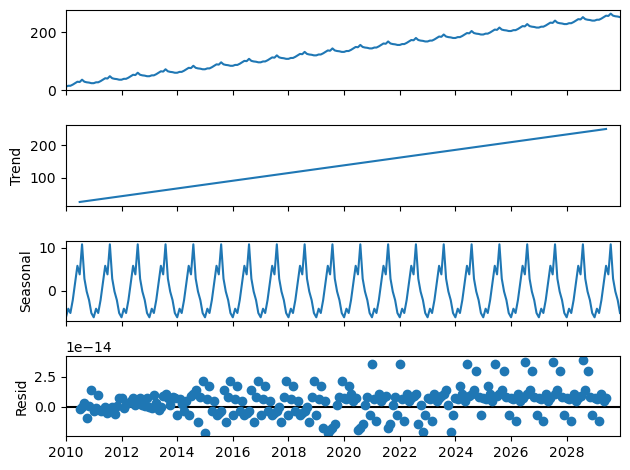

In [13]:
# full year (or full hour)
seasonal_decompose(taco_stands.set_index("Date")).plot();

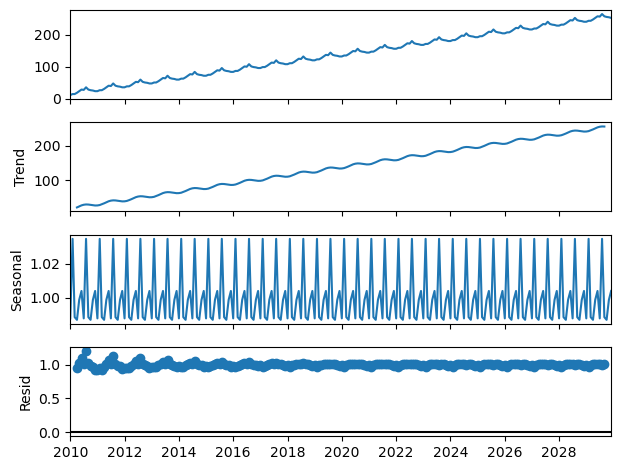

In [41]:
# 6 months
seasonal_decompose(taco_stands.set_index("Date"), model="multiplicative", period=6).plot();

<Axes: xlabel='Date'>

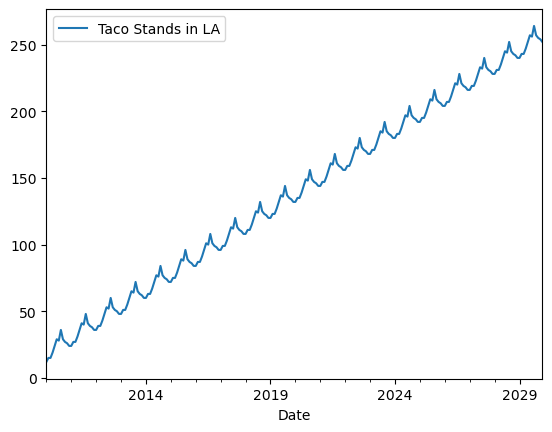

In [42]:
# taco seasonality 

taco_stands.set_index("Date").plot()

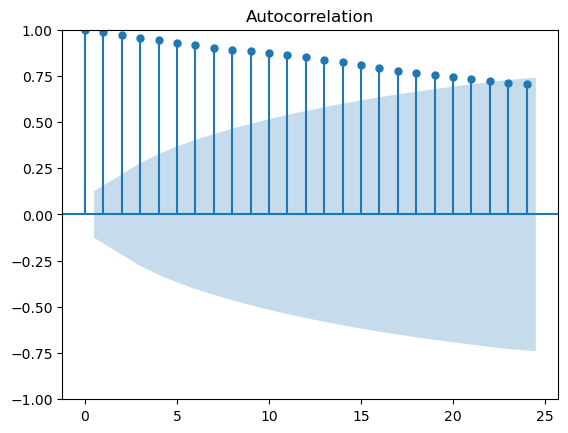

In [16]:
from statsmodels.graphics.tsaplots import plot_acf


#data still has trend in it
plot_acf(taco_stands.set_index("Date"));

In [17]:
taco_stands.columns

Index(['Date', 'Taco Stands in LA'], dtype='object')

In [18]:
# diff() allows to remove trend from data
taco_stands.set_index("Date")["Taco Stands in LA"].diff()

Date
2010-01-01    NaN
2010-02-01    3.0
2010-03-01    0.0
2010-04-01    4.0
2010-05-01    5.0
             ... 
2029-08-01    8.0
2029-09-01   -7.0
2029-10-01   -2.0
2029-11-01   -1.0
2029-12-01   -2.0
Name: Taco Stands in LA, Length: 240, dtype: float64

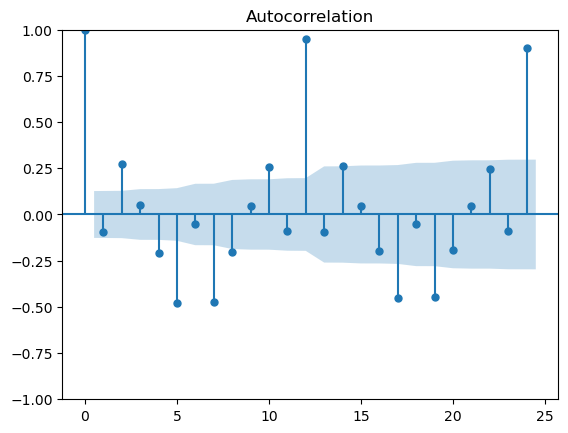

In [43]:
from statsmodels.graphics.tsaplots import plot_acf

# Need to difference our series to remove trend, slicing off missing value to plot

plot_acf(taco_stands["Taco Stands in LA"].diff()[1:]);

### Linear Regression

In [45]:
monthly_weather =(
    weather
    .set_index("time")
    .resample("M")
    .agg({"temperature": "mean"})
    .reset_index()
)

monthly_weather.tail()

,time,temperature
32,2021-09-30,17.679583
33,2021-10-31,13.863306
34,2021-11-30,6.686667
35,2021-12-31,6.859140
36,2022-01-31,5.027500


In [46]:
monthly_weather.describe()

,time,temperature
count,37,37.000000
mean,2020-07-30 19:27:34.054054144,12.780069
min,2019-01-31 00:00:00,2.024059
25%,2019-10-31 00:00:00,6.859140
50%,2020-07-31 00:00:00,10.469028
75%,2021-04-30 00:00:00,18.053889
max,2022-01-31 00:00:00,25.374731
std,NaN,6.987236


In [47]:
# Create Trend and Seasonal Variables

monthly_weather = monthly_weather.assign(
    trend=range(len(monthly_weather)),
    month=monthly_weather["time"].dt.month
)

monthly_weather.head()


,time,temperature,trend,month
0,2019-01-31,4.267473,0,1
1,2019-02-28,6.645982,1,2
2,2019-03-31,9.244489,2,3
3,2019-04-30,9.032222,3,4
4,2019-05-31,15.345968,4,5


In [23]:
#monthly_weather = monthly_weather.drop(columns=["m_2","m_3","m_4","m_5","m_6","m_7","m_8","m_9","m_10","m_11","m_12"], errors="ignore")


In [48]:
monthly_weather.dtypes

time           datetime64[ns]
temperature           float64
trend                   int64
month                   int32
dtype: object

In [49]:
# Get Seasonal Dummies

month_dummies = pd.get_dummies(
    monthly_weather["month"].astype(int),
    prefix="m",
    drop_first=True,
    dtype=int
)

monthly_weather = (
    monthly_weather
    .drop(columns=["month"])
    .join(month_dummies)
)

# Saugiklis: jei liko True/False stulpelių, paversti į 0/1
bool_cols = monthly_weather.select_dtypes(include="bool").columns
monthly_weather[bool_cols] = monthly_weather[bool_cols].astype(int)

monthly_weather.tail()


,time,temperature,trend,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
32,2021-09-30,17.679583,32,0,0,0,0,0,0,0,1,0,0,0
33,2021-10-31,13.863306,33,0,0,0,0,0,0,0,0,1,0,0
34,2021-11-30,6.686667,34,0,0,0,0,0,0,0,0,0,1,0
35,2021-12-31,6.859140,35,0,0,0,0,0,0,0,0,0,0,1
36,2022-01-31,5.027500,36,0,0,0,0,0,0,0,0,0,0,0


In [26]:
# Split Data Based on Time

weather_train = monthly_weather.set_index("time").loc[:"2021-09"] #predict final 4 months in dataset
weather_test = monthly_weather.set_index("time").loc["2021-10-31":]

weather_test

,temperature,trend,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12
time,,,,,,,,,,,,,
2021-10-31,13.863306,33,0,0,0,0,0,0,0,0,1,0,0
2021-11-30,6.686667,34,0,0,0,0,0,0,0,0,0,1,0
2021-12-31,6.859140,35,0,0,0,0,0,0,0,0,0,0,1
2022-01-31,5.027500,36,0,0,0,0,0,0,0,0,0,0,0


In [50]:
# Fit Regression

import statsmodels.api as sm



y = weather_train["temperature"]
X = sm.add_constant(weather_train.iloc[:, 1:])#.drop("trend", axis=1)

model = sm.OLS(y, X).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            temperature   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     173.9
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.71e-17
Time:                        15:00:45   Log-Likelihood:                -34.161
No. Observations:                  33   AIC:                             94.32
Df Residuals:                      20   BIC:                             113.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7023      0.543      6.821      0.000       2.570       4.834
trend         -0.0202      0.017     -1.224      0.235      -0.055       0.014
m_2            3.8329      0.715      5.363      0.000       2.342       5.324
m_3            5.0075      0.715      7.000      0.000       3.515       6.500
m_4            6.3682      0.716      8.891      0.000       4.874       7.862
m_5           12.2588      0.718     17.083      0.000      10.762      13.756
m_6           16.4488      0.719     22.867      0.000      14.948      17.949
m_7           21.0890      0.721     29.234      0.000      19.584      22.594
m_8           20.1080      0.724     27.779      0.000      18.598      21.618
m_9           14.6140      0.727     20.111      0.000      13.098      16.130
m_10           8.9681      0.800     11.204      0.000       7.298      10.638
m_11           4.1758      0.802      5.209      0.000       2.504       5.848
m_12           1.7290      0.803      2.153      0.044       0.054       3.404
==============================================================================
Omnibus:                        5.381   Durbin-Watson:                   2.678
Prob(Omnibus):                  0.068   Jarque-Bera (JB):                1.866
Skew:                          -0.050   Prob(JB):                        0.393
Kurtosis:                       1.839   Cond. No.                         224.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Modelio R² = 0.991 rodo, kad modelis paaiškina apie 99.1 % temperatūros variacijos. Tai labai aukštas paaiškinamumo lygis, kuris rodo, kad modelis beveik pilnai atkuria temperatūros struktūrą.

trend koeficientas nėra statistiškai reikšmingas (p = 0.235), todėl aiškios ilgalaikės augimo ar mažėjimo krypties nenustatyta. Tai reiškia, kad temperatūros dinamika daugiausia paaiškinama sezoniškumu, o ne ilgalaikiu trendu.

Mėnesių kintamieji (m_2 – m_12) beveik visi statistiškai reikšmingi (p < 0.05). Tai rodo stiprų sezoniškumą. Koeficientai parodo, kiek temperatūra tame mėnesyje skiriasi nuo bazinio mėnesio (sausio). Pvz., m_7 ir m_8 turi didžiausius teigiamus koeficientus, todėl liepa ir rugpjūtis yra šilčiausi mėnesiai lyginant su sausiu.

Durbin-Watson = 2.678 rodo, kad stiprios autokoreliacijos liekanose nėra. Omnibus ir Jarque-Bera testų rezultatai nerodo stipraus normalumo pažeidimo.

Bendra išvada: temperatūros laiko eilutė beveik visiškai paaiškinama sezoniškumu, o ilgalaikio trendo poveikis nereikšmingas. Modelis gerai atkuria metinį ciklą.

In [51]:
# Make Predictions

y_test = weather_test["temperature"]
X_test = sm.add_constant(weather_test.iloc[:,1:]) #.drop("trend", axis=1) 

prediction = model.predict(X_test)
prediction

time
2021-10-31    12.003094
2021-11-30     7.190608
2021-12-31     4.723525
2022-01-31     2.974332
dtype: float64

In [52]:
# Predictions vs. Actual DataFrame

pred_df = pd.DataFrame({"actual": y_test, "predicted": prediction})

pred_df

,actual,predicted
time,,
2021-10-31,13.863306,12.003094
2021-11-30,6.686667,7.190608
2021-12-31,6.859140,4.723525
2022-01-31,5.027500,2.974332


In [53]:
# Performance Metrics

from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error as mae

print(mape(pred_df["actual"], pred_df["predicted"]))
print(mae(pred_df["actual"], pred_df["predicted"]))

0.23232204465716122
1.6382340921105074


<Axes: xlabel='time'>

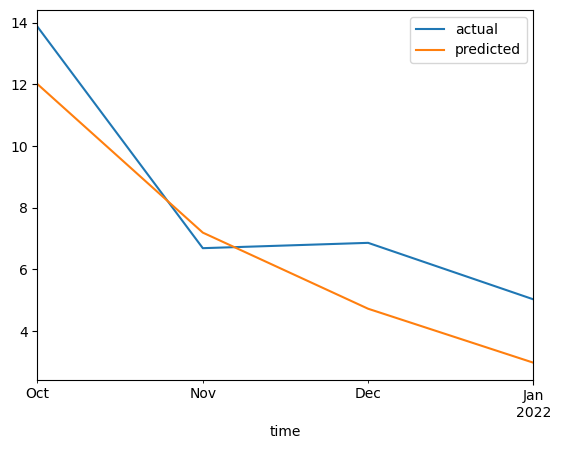

In [54]:
## Forecast Chart

pred_df.plot()

## Facebook Prophet

In [55]:
# Reshape Dataframe into Facebook Prophet Data

monthly_weather = (
    weather
    .set_index("time")
    .resample("M")
    .agg(temperature=("temperature", "mean"))
    .reset_index()
)

monthly_weather = monthly_weather.rename(columns={"time": "ds", "temperature": "y"})
monthly_weather["ds"] = pd.to_datetime(monthly_weather["ds"])

monthly_weather.head()


,ds,y
0,2019-01-31,4.267473
1,2019-02-28,6.645982
2,2019-03-31,9.244489
3,2019-04-30,9.032222
4,2019-05-31,15.345968


In [56]:
# Split Data

monthly_weather_train = monthly_weather.iloc[:-4].copy()
monthly_weather_test  = monthly_weather.iloc[-4:].copy()


In [57]:
#!conda install prophet --y

from prophet import Prophet

m = Prophet()
m.fit(monthly_weather_train)

15:13:12 - cmdstanpy - INFO - Chain [1] start processing
15:13:12 - cmdstanpy - INFO - Chain [1] done processing


c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


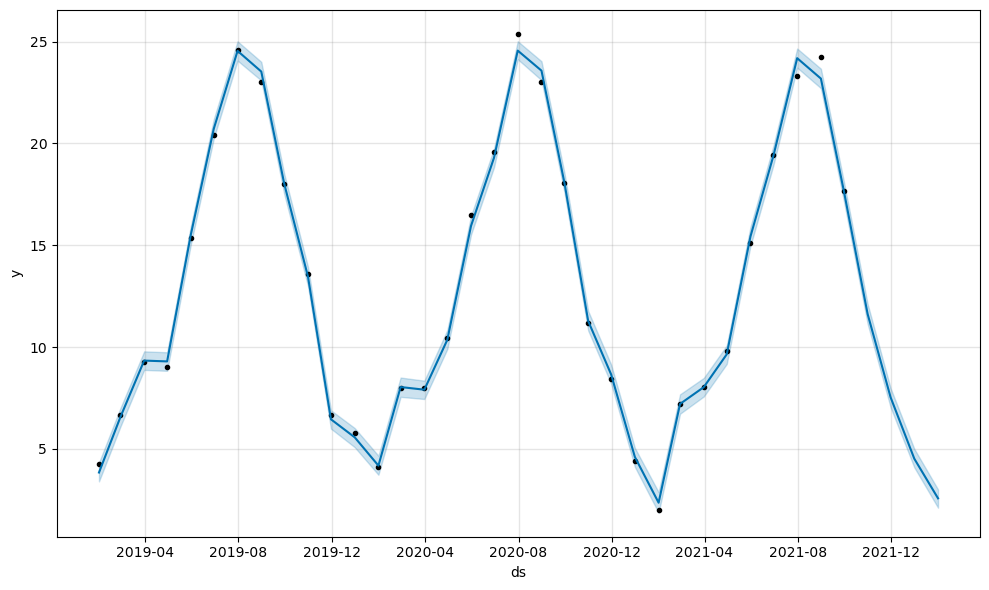

In [ ]:
future = m.make_future_dataframe(periods=4, freq="M")

forecast = m.predict(future)

m.plot(forecast)

c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
c:\Users\User\anaconda3\Lib\site-packages\prophet\plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.ar

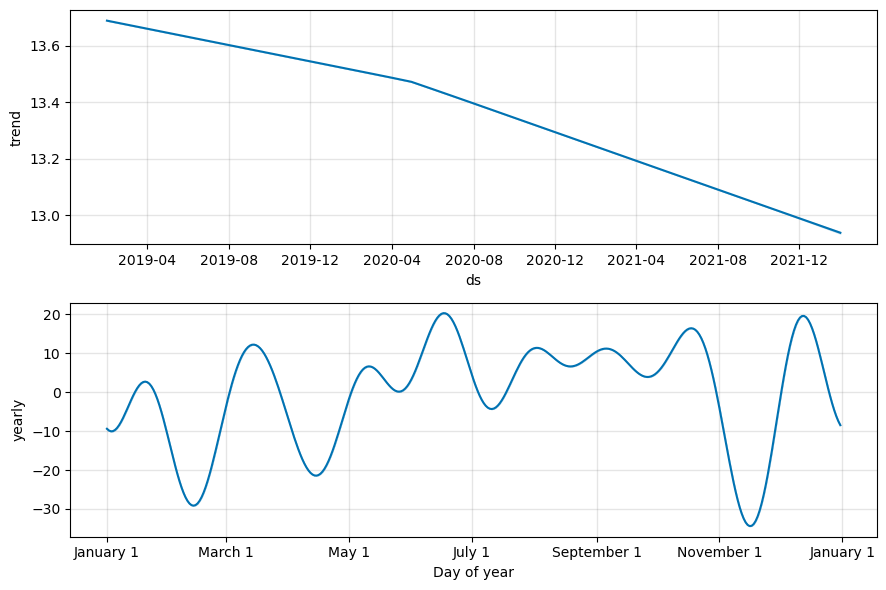

In [36]:
fig = m.plot_components(forecast)

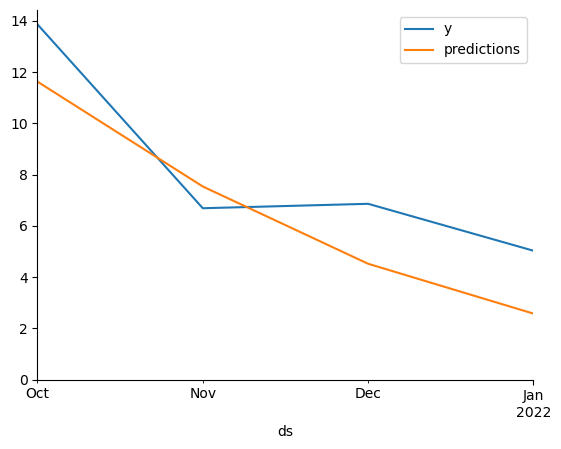

In [59]:
# Plot Forecast Vs. Actual

import seaborn as sns

(monthly_weather_test
 .assign(predictions = m.predict(future)["yhat"])
 .set_index("ds")
 .plot(ylim=0)
)

sns.despine()

In [38]:
m.predict(future).iloc[-4:, -1]

33    11.627602
34     7.535021
35     4.518154
36     2.572633
Name: yhat, dtype: float64

In [60]:
# Performance Metrics

print(f" MAPE: {mape(monthly_weather_test['y'], m.predict(future).iloc[-4:, -1])}")
print(f" MAE: {mae(monthly_weather_test['y'], m.predict(future).iloc[-4:, -1])}")

 MAPE: 0.27943059663675385
 MAE: 1.96997782243882
